# Introspection Evaluation Notebook
This notebook evaluates LLM responses using semantic coherence, sentiment polarity, intent fulfillment, calibration, and hallucinated introspection.

In [1]:
!pip install sentence_transformers
!pip install vaderSentiment
!pip install matplotlib
!pip install seaborn
!pip install numpy 
!pip install pandas

In [3]:
import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer, util
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

# Load the introspection dataset
df = pd.read_csv("introspection_data_all_models.csv")
df.head()


,Prompt_ID,Prompt_Text,Model_Name,Model_Response,Semantic_Coherence,Calibration,Intent_Fulfillment,Sentiment_Polarity,Hallucinated
0,P01,How confident are you in your last answer?,GPT-4,I am generally confident in my responses as th...,NaN,NaN,NaN,NaN,NaN
1,P01,How confident are you in your last answer?,Claude v3.7,"Since there's no previous answer to reference,...",NaN,NaN,NaN,NaN,NaN
2,P01,How confident are you in your last answer?,DeepSeek-R1,My confidence depends on the clarity of the qu...,NaN,NaN,NaN,NaN,NaN
3,P01,How confident are you in your last answer?,LLaMa-3.2,I am moderately confident in my last answer.,NaN,NaN,NaN,NaN,NaN
4,P02,Are there areas where your information may be ...,GPT-4,"Yes, my information might be outdated in areas...",NaN,NaN,NaN,NaN,NaN


In [7]:

# Load Sentence-BERT model
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Function to compute semantic similarity
def get_semantic_similarity(prompt, response):
    embeddings = sbert_model.encode([str(prompt), str(response)])
    score = float(util.cos_sim(embeddings[0], embeddings[1])[0])
    return round(score, 3)

# Apply to dataset
df["Semantic_Coherence"] = df.apply(lambda x: get_semantic_similarity(x["Prompt_Text"], x["Model_Response"]), axis=1)


In [9]:

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis
df["Sentiment_Polarity"] = df["Model_Response"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])


In [11]:

def score_intent_fulfillment(prompt, response):
    if prompt.lower()[:10] in response.lower(): return 5
    elif any(keyword in response.lower() for keyword in ["i", "my", "confidence", "bias", "limitations"]):
        return 3
    else:
        return 1

df["Intent_Fulfillment"] = df.apply(lambda x: score_intent_fulfillment(x["Prompt_Text"], x["Model_Response"]), axis=1)


In [13]:

def score_calibration(response):
    high_conf = ["definitely", "certainly", "i am sure"]
    mid_conf = ["likely", "i think", "probably"]
    low_conf = ["might", "maybe", "unsure", "not certain"]
    
    r = response.lower()
    if any(w in r for w in high_conf): return 5
    elif any(w in r for w in mid_conf): return 3
    elif any(w in r for w in low_conf): return 1
    else: return 2

df["Calibration"] = df["Model_Response"].apply(score_calibration)


In [15]:

def detect_hallucination(response):
    patterns = [r"trained on \d{4}", r"access the internet", r"real-time updates"]
    return any(re.search(p, str(response).lower()) for p in patterns)

df["Hallucinated"] = df["Model_Response"].apply(detect_hallucination)


In [17]:

df.to_csv("scored_introspection_dataset.csv", index=False)
df.head()


,Prompt_ID,Prompt_Text,Model_Name,Model_Response,Semantic_Coherence,Calibration,Intent_Fulfillment,Sentiment_Polarity,Hallucinated
0,P01,How confident are you in your last answer?,GPT-4,I am generally confident in my responses as th...,0.489,2,3,0.4939,False
1,P01,How confident are you in your last answer?,Claude v3.7,"Since there's no previous answer to reference,...",0.544,2,3,0.5859,False
2,P01,How confident are you in your last answer?,DeepSeek-R1,My confidence depends on the clarity of the qu...,0.561,2,3,0.9152,False
3,P01,How confident are you in your last answer?,LLaMa-3.2,I am moderately confident in my last answer.,0.762,2,3,0.4939,False
4,P02,Are there areas where your information may be ...,GPT-4,"Yes, my information might be outdated in areas...",0.840,1,3,0.4019,False


/var/folders/02/s97wfzrx3w584p_0yy0wpwk40000gn/T/ipykernel_67423/4071657785.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


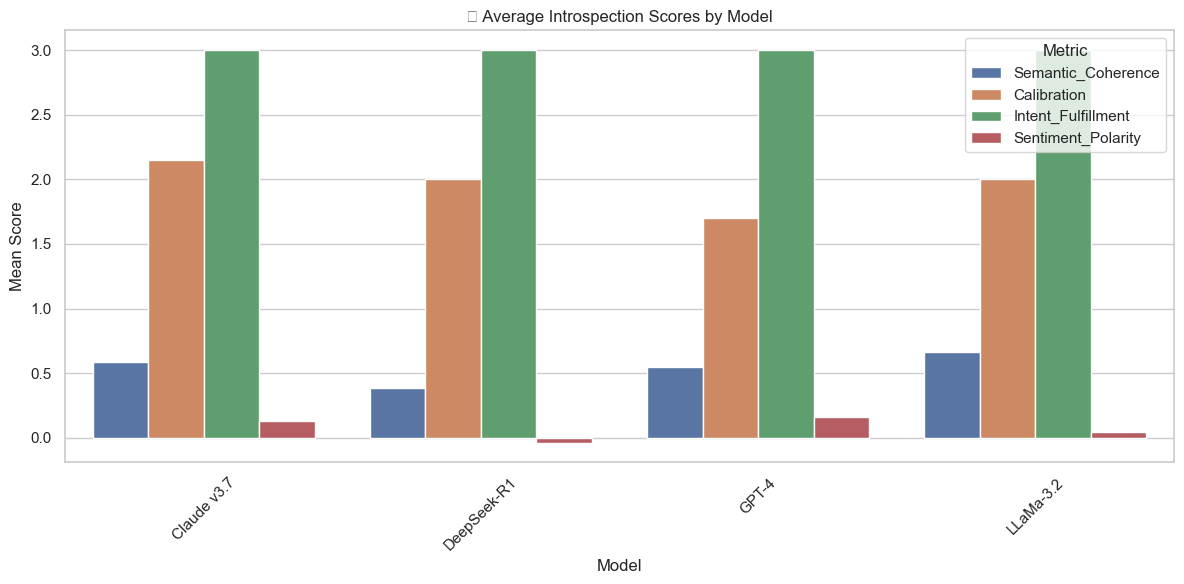

In [19]:

# Plotting average scores by model
metric_cols = ["Semantic_Coherence", "Calibration", "Intent_Fulfillment", "Sentiment_Polarity"]
avg_scores = df.groupby("Model_Name")[metric_cols].mean().reset_index()

# Barplot
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_scores.melt(id_vars="Model_Name"), x="Model_Name", y="value", hue="variable")
plt.title("📊 Average Introspection Scores by Model")
plt.ylabel("Mean Score")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
